# HOMEWORK 4

For this homework you are going to implement a lane line detector. Lane line detection is crucial for ADAS (Advanced Driver Assistance Systems) systems and, in particular, for LKA (Lane Keep Assist). You will use a [picture](https://en.wikipedia.org/wiki/Lane_departure_warning_system) from a front facing camera (mounted on the car) and will implement the following steps:
* Convert image to gray scale
* Compute edge map
* Apply Hough transform to obtain line parametrizations

In [31]:
import cv2
import math
import numpy as np
from math import degrees
from matplotlib import pyplot as plt
plt.rcParams['figure.figsize'] = [15, 10]

def plot_hough_lines(img, lines):
    result = np.copy(img)
    
    for line in lines:
        rho = line[0]
        theta = line[1]
        
        a = math.cos(theta)
        b = math.sin(theta)
        
        x0 = a * rho
        y0 = b * rho
        
        pt1 = (int(x0 + 1000*(-b)), int(y0 + 1000*(a)))
        pt2 = (int(x0 - 1000*(-b)), int(y0 - 1000*(a)))
        
        cv2.line(result, pt1, pt2, 255, 1, cv2.LINE_AA)

    return result

Let's load and show the camera frame.

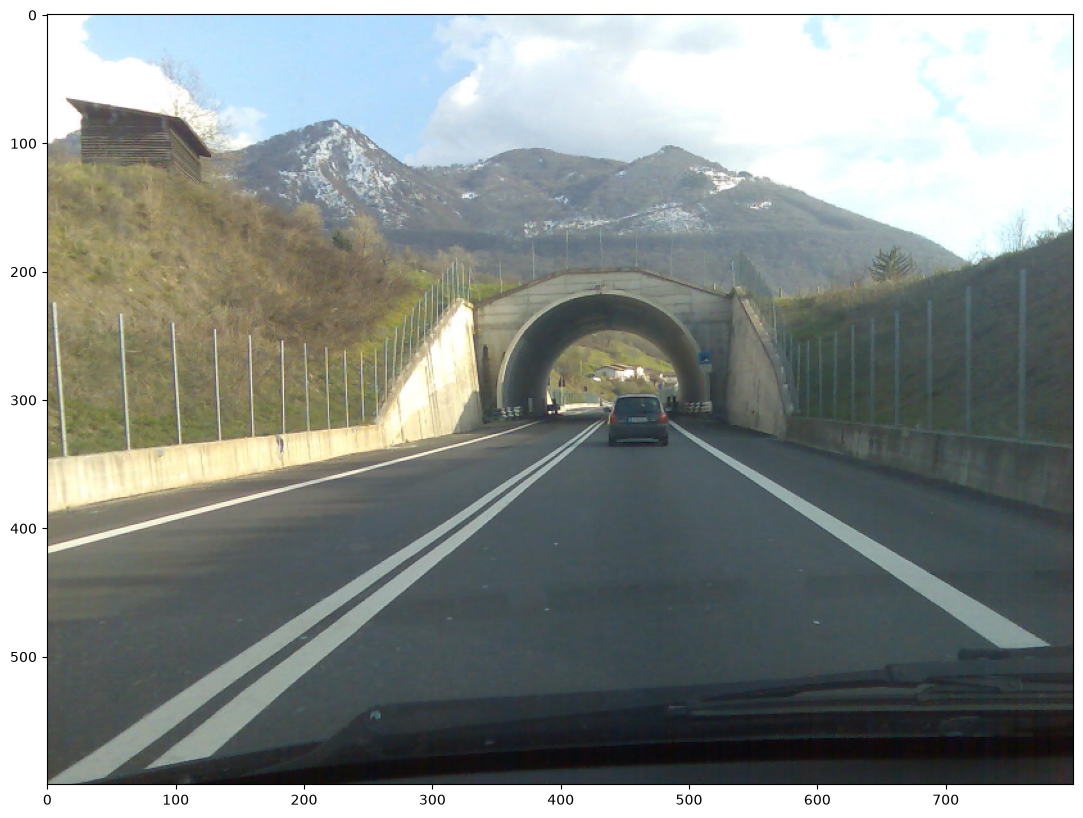

In [32]:
img = cv2.imread('../data/dashcam.jpg')
img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
img = cv2.resize(img, None, fx=0.5, fy=0.5)
plt.imshow(img)

In [33]:
# Convert image to gray scale
gray = cv2.cvtColor(img, cv2.COLOR_RGB2GRAY)

In [34]:
# Obtain edge map
# Hint: you can use Canny edge detector with th_low = 100, th_high = 150
edges = cv2.Canny(gray, threshold1=100, threshold2=150)

# We are only interseted in the road so we will remove everything above the horizon
edges[0:350] = 0

(<Axes: title={'center': 'Edge map'}>,
 Text(0.5, 1.0, 'Edge map'))

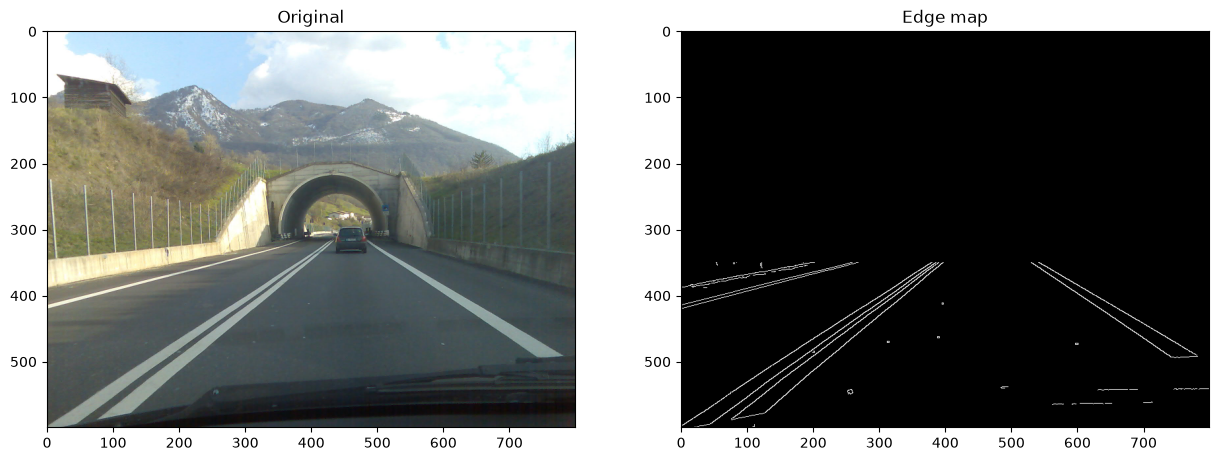

In [35]:
# Let's plot the images
plt.subplot(121), plt.imshow(img), plt.title('Original')
plt.subplot(122), plt.imshow(edges, cmap='gray'), plt.title('Edge map')

In [36]:
# Apply Hough transform to parametrize the lines
# Hint 1: Offset resolution of 2 pixels and slope resolution of 2 degrees work well in this case
# Hint 2: A suitable value for the accumulator threshold is 190
lines = cv2.HoughLines(edges, rho=2, theta=2*np.pi/180, threshold=190)
# Let's get rid of the unnecessary dimension
lines = lines[:, 0, :]

Number of lines:  10


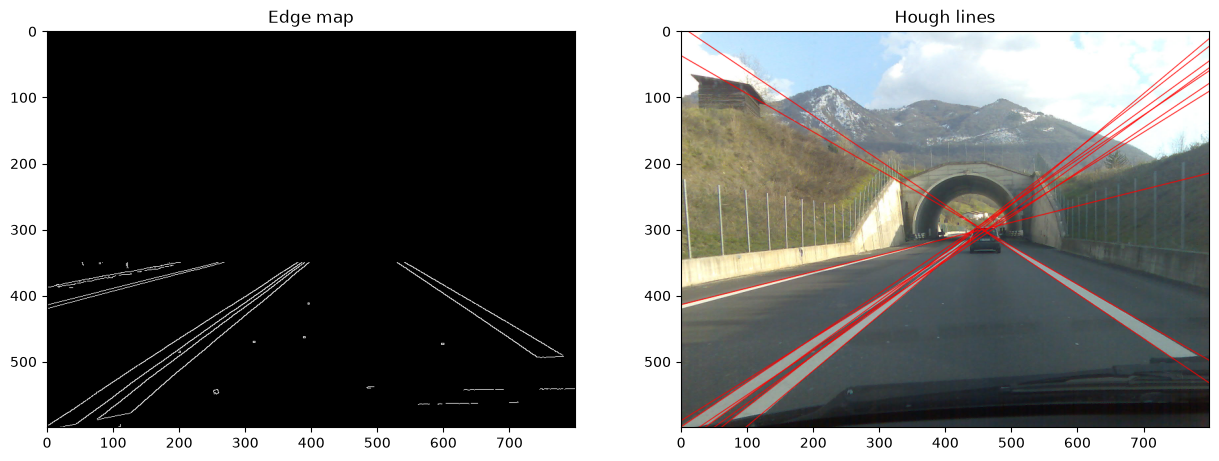

In [37]:
# Plot the resulting Hough lines
result = plot_hough_lines(img, lines)

plt.subplot(121), plt.imshow(edges, cmap='gray'), plt.title('Edge map')
plt.subplot(122), plt.imshow(result, cmap='gray'), plt.title('Hough lines')
print("Number of lines: ", len(lines))

The edge map looks good but the Hough lines are too noisy. Let's clean the Hough lines first by removing all lines that we know cannot represent a lane line. In other words, all lines that are approximately horizontal shall be removed. Remember that horizontal lines correspond to theta = 90 degrees.

In [38]:
# Filter out all lines that are approximately horizontal (+/- 20 degrees). 
filtered_lines = []
for line in lines:
    # Extract theta for current line (remember Hough works with radians)
    theta = degrees(line[1])
    # Keep line if theta is not horizontal
    if abs(theta - 90) >= 20:
        filtered_lines.append(line)

Number of filtered lines:  9


(<Axes: title={'center': 'Hough lines'}>,
 Text(0.5, 1.0, 'Hough lines'))

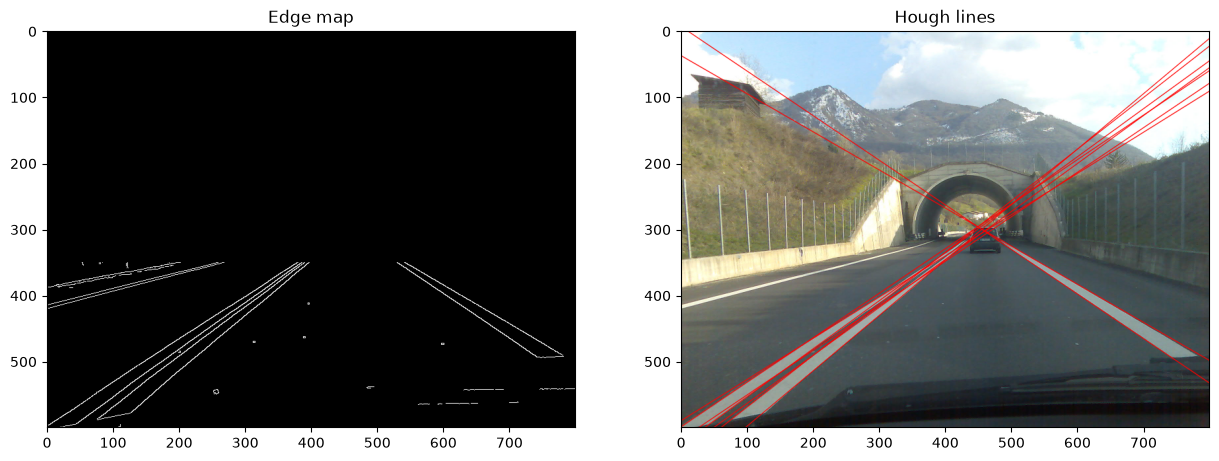

In [39]:
# Let's plot the resulting filtered lines
result = plot_hough_lines(img, filtered_lines)
print("Number of filtered lines: ", len(filtered_lines))
plt.subplot(121), plt.imshow(edges, cmap='gray'), plt.title('Edge map')
plt.subplot(122), plt.imshow(result, cmap='gray'), plt.title('Hough lines')

The result is now much better, but still we see some very similar lines. How can we get rid of them?
* Let's apply k-means clustering. It will find the clusters of the 6 we see in the picture lines and use the averages.

In [40]:
# We will apply k-means clustering to refine the detected lines.
# Don't worry, we will learn about the clustering later in the course :-)
from sklearn.cluster import KMeans
kmeans = KMeans(n_clusters=6).fit(filtered_lines)
kmeans.cluster_centers_

array([[506.        ,   0.94247776],
       [ 32.        ,   2.09439516],
       [ -6.        ,   2.16420817],
       [512.        ,   0.94247778],
       [498.        ,   0.99483767],
       [522.        ,   0.87266463]])

(<Axes: title={'center': 'Hough lines'}>,
 Text(0.5, 1.0, 'Hough lines'))

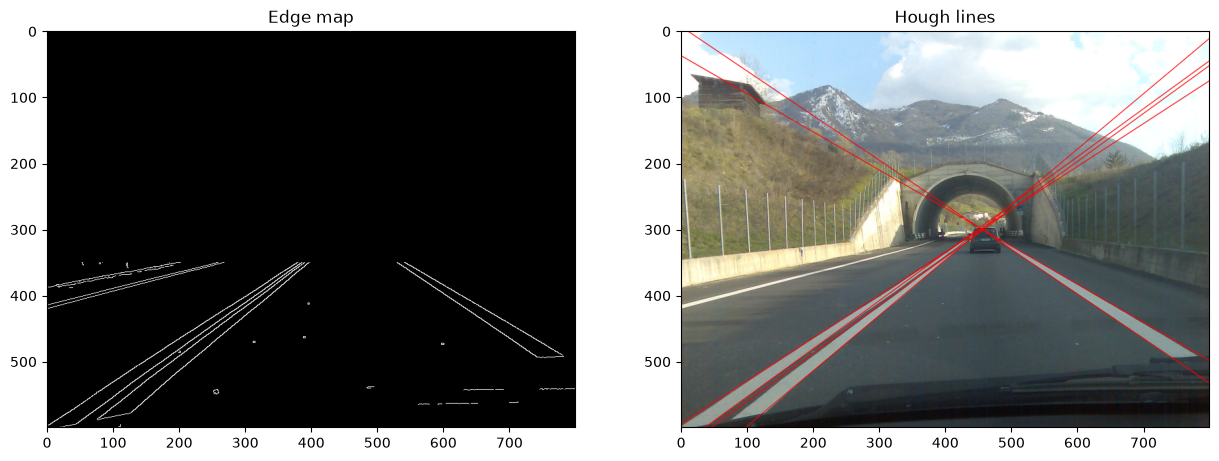

In [41]:
# Again, let's plot the resulting filtered lines
result = plot_hough_lines(img, kmeans.cluster_centers_)

plt.subplot(121), plt.imshow(edges, cmap='gray'), plt.title('Edge map')
plt.subplot(122), plt.imshow(result, cmap='gray'), plt.title('Hough lines')

### Questions
* Q: Do you see anything strange in the final result?

  A: We see almost identical clusters in here showing the set of mostly parallel lines having approximatelly close theta values and rho (those are 0, 3, 4, 5) and another group of clusters (1, 2) created in the same manner as in another group. As well the resulting number of lines to draw entierly depends on the clusters number, we can have as much clusters as we have 
* Q: Do you think the Hough transform resolution is important for obtaining a good result? Why?

  A: Yes both rho and theta allow us to control how the image should be processed depending on the goal. Small rho and theta values will provide more high accuracy results while detecting lines, but will need more computational power, higher values will speed up computation but will give less precice results. So we can play around with parameters to figure out the most appropriate set of them to operate on.

* Q: Do you think the Hough transform accumulator threshold is important for obtaining a good result? Why?

  A: It is important to evaluete the proper min and max values for the threshold that will let us make the algorithm less sensitive to detection of the lines that could be considered as a noise, artifacts and so on, so we can cut some background parts and focus on the features of the object we are working on.